Part 1 - Linear regression

Importing libraries for data manipulation and visualisation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Importing dataset

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Exploratory Data Analysis (EDA)

Understanding and examining the structure of the dataset

In [3]:
df.shape
df.columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataset has 7 columns in total, it has 6 independent variables and 1 dependent variable.
There are 1338 entries (Rows & Columns). There are 3 numerical data types being age, bmi and charges.
There are also 3 categorical data types being sex, smoker and region. 
Dataset does not have any missing values.

Following I will be checking for duplicates

In [4]:
df.duplicated().sum()

np.int64(1)

I have discovered that there is 1 duplicate which I will then drop below

In [5]:
df = df.drop_duplicates()

I will then examine the different categories of categorical variables / columns

In [6]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [7]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [8]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

Data Visualization

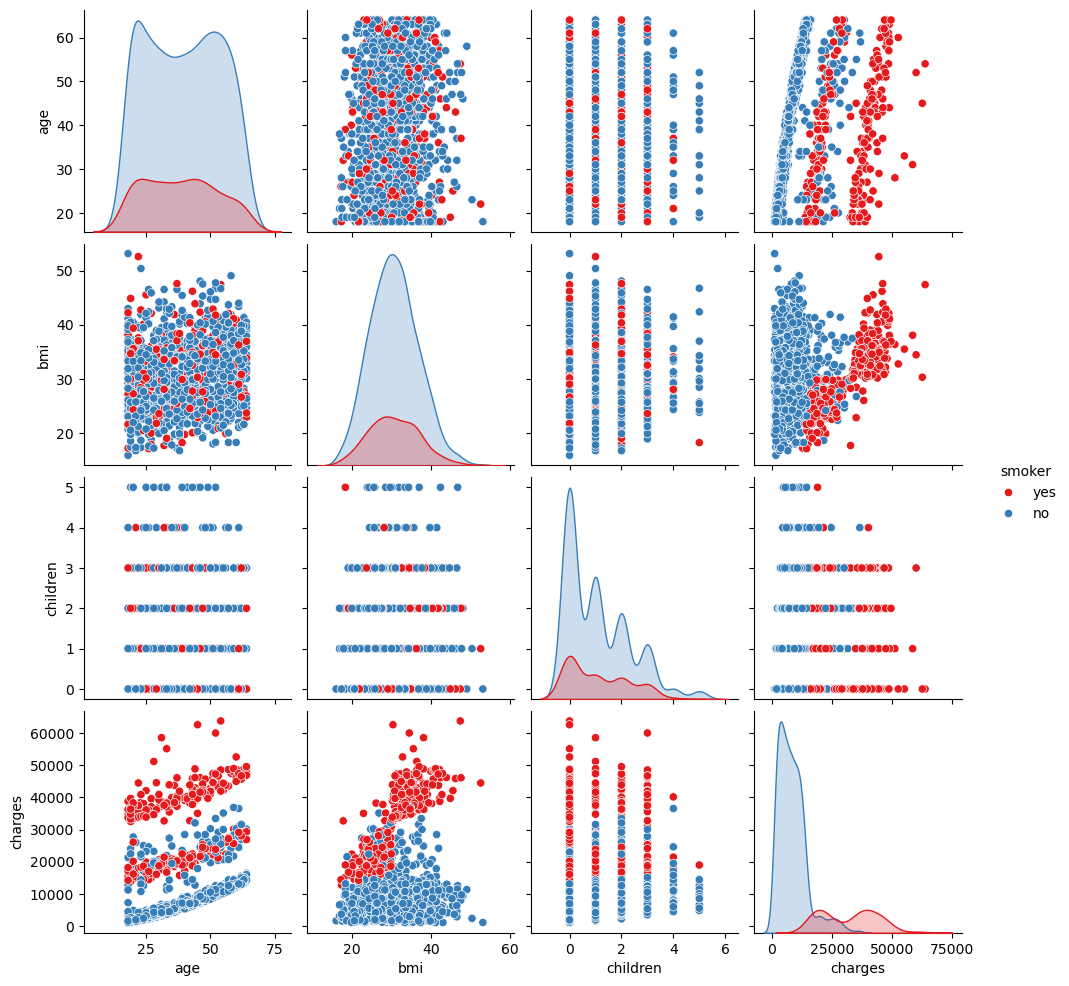

In [9]:
sns.pairplot(
    df, 
    vars=['age', 'bmi', 'children', 'charges'], 
    hue='smoker', 
    palette='Set1', 
    diag_kind='kde'
)
plt.show()

Above is a pairplot, this visualization helps in understanding the relationships between multiple variables simultaneously, it helps in visualizing how multiple variables relate to each other. Smokers are concentrated in the higher charges range.
Smoking is the strongest cost driver. Higher BMI often corresponds to higher charges, especially for smokers. Non-smokers with high BMI still cost more than low BMI clients. Clients with more children show slightly higher charges. The trend is weaker compared to age or BMI. Number of dependents has a small positive effect on costs.

below is a Scatterplot - Age vs Charges

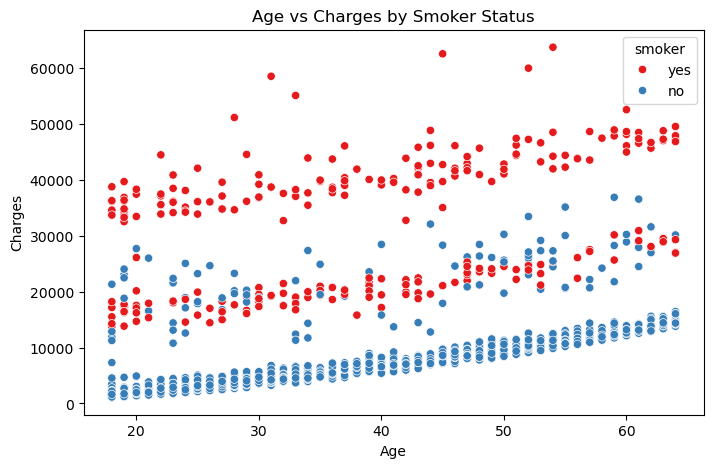

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='Set1')
plt.title("Age vs Charges by Smoker Status")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

The plot shows a positive trend – as age increases, charges also increase. Age is a strong predictor and smoker status amplifies costs.

Below is a Scatterplot for BMI vs Charges

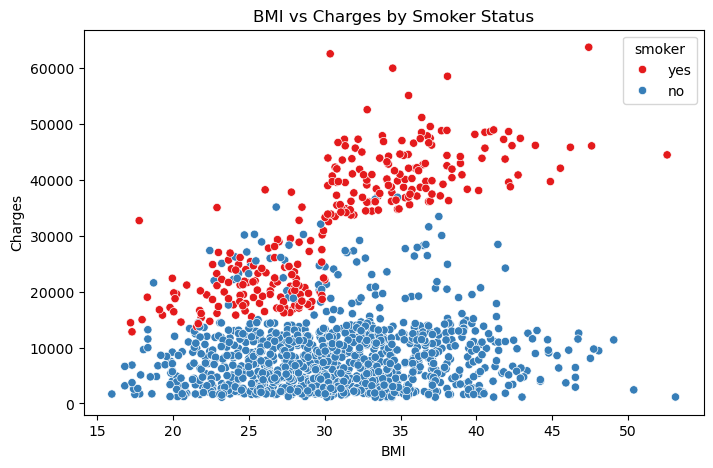

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='Set1')
plt.title("BMI vs Charges by Smoker Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

There is a slight upward trend – higher BMI often corresponds to higher charges. BMI is a moderate predictor and its effect interacts with smoker status.

Next I will do the boxplot visualizations

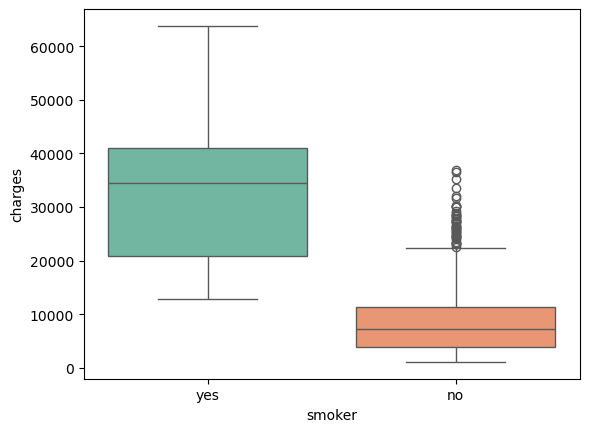

In [12]:
sns.boxplot(
    x='smoker', 
    y='charges', 
    data=df, 
    palette='Set2', 
    hue='smoker', 
    legend=False
)

plt.show()

This plot shows Smoker vs Charges, smokers have a much higher median charge than non-smokers. Some smokers have extremely high charges, forming a long upper whisker. Smoking is the strongest cost driver, it significantly increases medical aid charges.

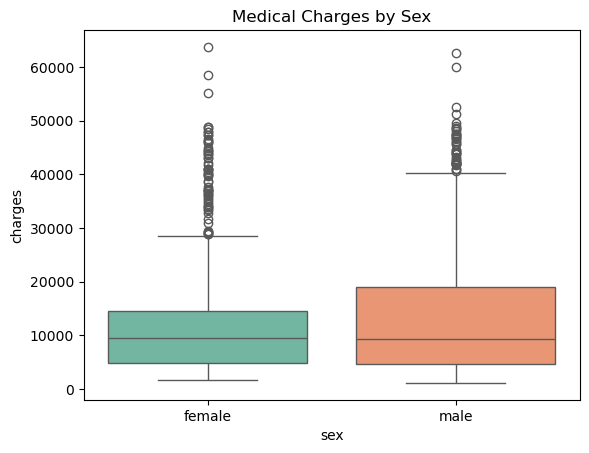

In [13]:
sns.boxplot(
    data=df, 
    x='sex', 
    y='charges', 
    hue='sex', 
    palette='Set2', 
    legend=False
)

plt.title('Medical Charges by Sex')
plt.show()

This plot shows Sex vs Charges, there is minimal difference between males and females in median charges. Sex has a small effect on charges.

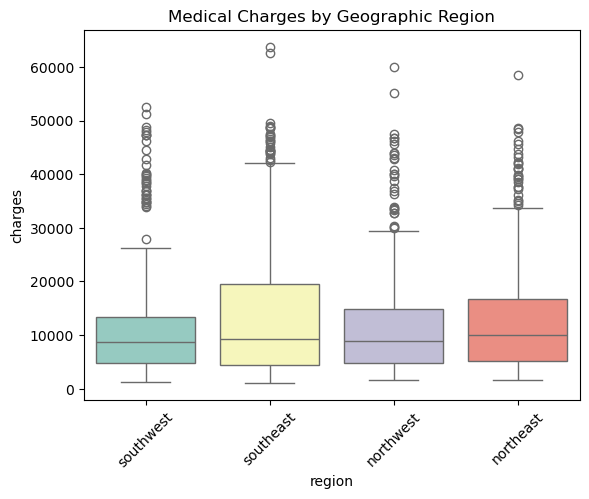

In [14]:
sns.boxplot(
    data=df, 
    x='region', 
    y='charges', 
    hue='region', 
    palette='Set3', 
    legend=False
)

plt.title('Medical Charges by Geographic Region')
plt.xticks(rotation=45) 
plt.show()

This plot shows Region vs Charges, All regions have high-cost outliers but the median differences indicate regional variation in costs.Region is a moderate predictor; it reflects geographic differences in healthcare costs.

Encoding categorical variables - Convert categorical variables into numeric form

Since mathematical equations cannot 'read' text like 'Smoker or 'Region', I will convert these categorical variables into a numerical format and this is done by means of encoding.

In [49]:
df_encoded = pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Feature Selection - Correlation Analysis

Feature selection helps identify which variables have the most significant impact on insurance charges.

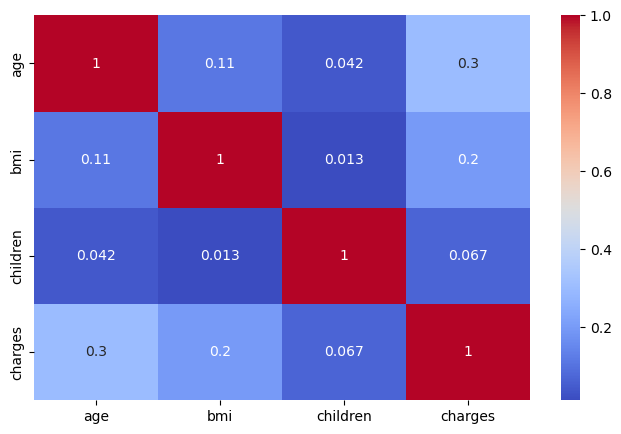

In [17]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Feature Importance

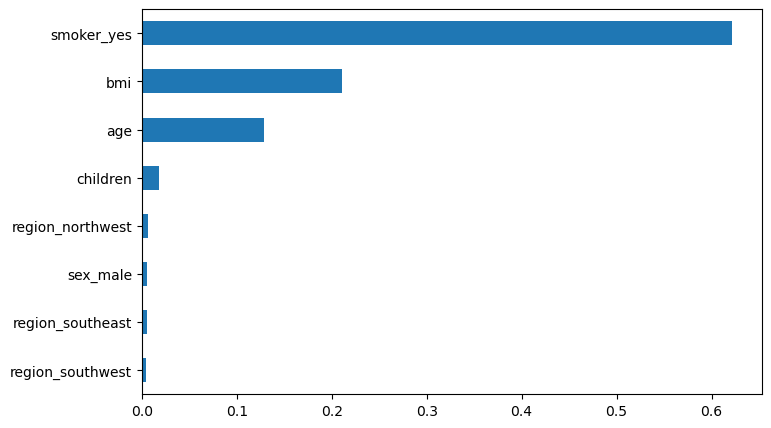

In [20]:
from sklearn.ensemble import RandomForestRegressor

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.show()

Recursive Feature Elimination

In [24]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
rfe = RFE(lr, n_features_to_select=3)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print(selected_features)

Index(['children', 'smoker_yes', 'region_southeast'], dtype='object')


Final selection

Smoker is a very strong predictor, followed by mbi and age respectively, children show weak and I will drop the region and sex as they prove to have low impact.

Training model

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predictions

In [27]:
y_pred = model.predict(X_test)

Evaluating linear regression model performance

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print ('Linear regression performance:')
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Linear regression performance:
Root Mean Squared Error (RMSE): 5956.34
R-squared (R2 Score): 0.8069


The model shows a decent linear relationship
This is good, indicating the model captures most of the variability